In [1]:
import numpy as np
import torch
import torch_geometric as tg
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:


class GNNModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=None, bias=False, num_layers=1, conv_type='GCN'):
        super(GNNModel, self).__init__()

        self.convs = torch.nn.ModuleList()

        for _ in range(num_layers - 1):
            if conv_type == 'GCN':
                self.convs.append(tg.nn.GCNConv(in_channels, hidden_channels, bias=bias))
            elif conv_type == 'GraphSAGE':
                self.convs.append(tg.nn.SAGEConv(in_channels, hidden_channels, bias=bias, aggr='sum'))
            elif conv_type == 'GAT':
                self.convs.append(tg.nn.GATConv(in_channels, hidden_channels, bias=bias))
            elif conv_type == 'GIN':
                nn = tg.nn.MLP([in_channels, hidden_channels, hidden_channels])
                self.convs.append(tg.nn.GINConv(nn))

        if out_channels is None:
            out_channels = hidden_channels
        if num_layers == 1:
            hidden_channels = in_channels
        if conv_type == 'GCN':
            self.conv = tg.nn.GCNConv(hidden_channels, out_channels, bias=bias)
        elif conv_type == 'GraphSAGE':
            self.conv = tg.nn.SAGEConv(hidden_channels, out_channels, bias=bias, aggr='sum')
        elif conv_type == 'GAT':
            self.conv = tg.nn.GATConv(hidden_channels, out_channels, bias=bias)
        elif conv_type == 'GIN':
            nn = tg.nn.MLP([hidden_channels, hidden_channels, out_channels])
            self.conv = tg.nn.GINConv(nn)
        else:
            raise ValueError(f"Convolution type {conv_type} not recognized.")
        self.convs.append(self.conv)
        self.num_features = hidden_channels

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        for conv in self.convs[:-1]:
            x = conv(x, edge_index).relu()
        x = self.convs[-1](x, edge_index)
        return x 



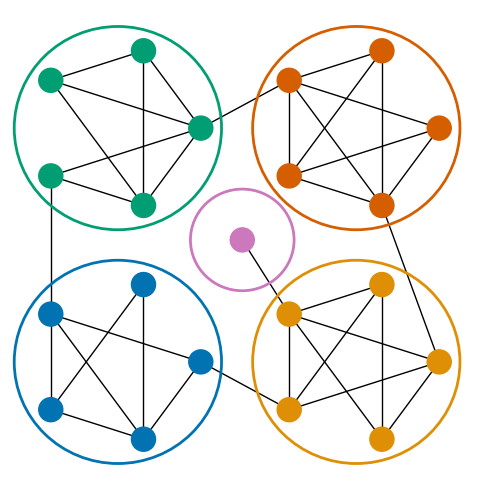

In [ ]:
from torch_geometric.utils import to_networkx
# import itertools
# # create from scratch a graph with 4 cliques of size 5
# np.random.seed(34)
n = 21
clusters =[[i for i in range(j*5, (j+1)*5)] for j in range(4)]
clusters += [[20]]
# edges = []

# for cluster in clusters:
#     for u, v in itertools.combinations(cluster, 2):
#         # with p=0.2 do not add the edge
#         if np.random.rand() > 0.175:
#             edges.append((u, v))
#             edges.append((v, u))

# # append some random edges between clusters
# edges.extend([(0, 8), (10, 17), (8, 0), (17, 10), (13, 2), (2, 13), (19, 5), (5, 19), (20, 7), (7,20)])


# G = nx.Graph(nodes=range(n))
# G.add_edges_from(edges)
# print(G.number_of_nodes())
# print(G.number_of_edges())

# edge_index = torch.tensor(edges).t().contiguous()
# x = torch.nn.Embedding(n, 32, _freeze=True).weight
# g = tg.data.Data(x=x, edge_index=edge_index)
# g.W = torch.ones((n, n))*(-1)
# for u, v in edges:
#     g.W[u, v] = 1.0
#     g.W[v, u] = 1.0
# g.W.fill_diagonal_(0)
# g.num_nodes = n

# torch.save(g, 'example_graph.pt')

g = torch.load('example_graph.pt', weights_only=False)
G = to_networkx(g, to_undirected=True)
# now create positions for each node in circles
pos = {}
for i in range(4):
    angle = 2 * np.pi / 5
    radius = 8
    center_x = (i % 2) * 23
    center_y = (i // 2) * 23
    for j in range(5):
        x = center_x + radius * np.cos(j * angle)
        y = center_y + radius * np.sin(j * angle)
        pos[i * 5 + j] = (x, y)

pos[20] = (12.0, 12.0)

colors = []
# use a colorblind friendly palette
color_names = sns.color_palette("colorblind", 5).as_hex()
for i in range(5):
    colors.extend([color_names[i]] * len(clusters[i]))





fig, ax = plt.subplots(figsize=(5, 5))
nx.draw(G, pos, with_labels=False, node_color=colors, edge_color='black')

# draw a circle around each cluster
for i, cluster in enumerate(clusters):
    radius = 10 if i < 4 else 5
    circle = plt.Circle((np.mean([pos[node][0] for node in cluster]), np.mean([pos[node][1] for node in cluster])), radius, color=color_names[i], fill=False, linewidth=2)
    ax.add_artist(circle)

plt.tight_layout()
plt.show()
#fig.savefig('./results/final/example_graph.pdf')


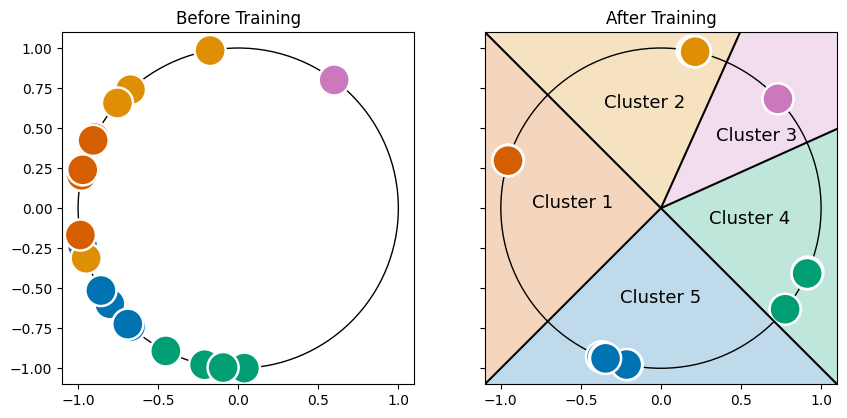

<Figure size 640x480 with 0 Axes>

In [ ]:


from matplotlib.pyplot import Polygon
from torch_geometric import seed_everything

seed_everything(33)
in_channels = 32
out_channels = 2

#pca = PCA(n_components=2)

model = GNNModel(in_channels, out_channels)
# plot the output when it is just initialised
out = model(g)
out = torch.nn.functional.normalize(out, p=2, dim=1)
out = out.detach().numpy()

#pca_out = out#pca.fit_transform(out)

# plot a unit sphere

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# plot a unit circle
circle = plt.Circle((0, 0), 1, color='black', fill=False)
ax[0].add_artist(circle)

# Set an equal aspect ratio
ax[0].set_aspect('equal')
sns.scatterplot(x=out[:, 0], y=out[:, 1], s=500, c=colors, ax=ax[0])
# # write number of each point
# for i in range(out.shape[0]):
#     ax[0].text(out[i, 0], out[i, 1], str(i), fontsize=12, ha='center', va='center')
ax[0].set_xlim(-1.1, 1.1)
ax[0].set_ylim(-1.1, 1.1)
ax[0].set_title('Before Training')

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# model.train()


# for epoch in range(5000):
#     out = model(g)
#     out = torch.nn.functional.normalize(out, p=2, dim=1)

#     dists = torch.cdist(out, out)
#     dists = dists / 2
#     #dists = dists / dists.max()

#     co_cluster_matrix = 1 - dists

#     loss = -torch.einsum("ij,ji->", g.W, co_cluster_matrix)
#     loss.backward()
#     optimizer.step()
#     optimizer.zero_grad()
#     # every 100 epochs plot out
# print('Final loss value (GNN):', loss.item())

# save model in example_gnn.pt
# torch.save(model.state_dict(), 'example_gnn.pt')


model.load_state_dict(torch.load('example_gnn.pt'))

model.eval()
out = model(g)
out = torch.nn.functional.normalize(out, p=2, dim=1)
out = out.detach().numpy()

#ax = fig.add_subplot(projection='3d')
#ax.plot_surface(x, y, z, alpha=0.2)
circle = plt.Circle((0, 0), 1, color='black', fill=False)
ax[1].add_artist(circle)
# Set an equal aspect ratio
ax[1].set_aspect('equal')
sns.scatterplot(x=out[:, 0], y=out[:, 1], s=500, c=colors, ax=ax[1])
ax[1].set_xlim(-1.1, 1.1)
ax[1].set_ylim(-1.1, 1.1)
ax[1].set_title('After Training')
# plot lines separating the clusters
ax[1].plot([-2, 0], [-2, 0], color='black')
ax[1].plot([-2, 2], [2, -2], color='black')
ax[1].plot([0.9, 0], [2, 0], color='black')
ax[1].plot([2, 0], [0.9, 0], color='black')
# add cluster names
cluster_names = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

fontsize = 13
ax[1].annotate('Cluster 1', (-0.3, 0), fontsize=fontsize, ha='right')
ax[1].annotate('Cluster 4', (0.3, -0.1), fontsize=fontsize, ha='left')
ax[1].annotate('Cluster 2', (-0.1, 0.6), fontsize=fontsize, ha='center', va='bottom')
ax[1].annotate('Cluster 5', (0, -0.5), fontsize=fontsize, ha='center', va='top')
ax[1].annotate('Cluster 3', (0.6, 0.45), fontsize=fontsize, ha='center', va='center')

# color the background of each quadrant defined by the 2 lines (-1, -1) to (1, 1) and (-1, 1) to (1, -1)
# each quadrant has a light color corresponding to the cluster colors

limit = 2.0
limit_2 = 0.9
# triangles anchored at origin split by the two diagonals
polygons = [
    [(0, 0), (limit, -limit), (-limit, -limit)],  # bottom wedge
    [(0, 0), (-limit, limit), (limit_2, limit)],   # top wedge
    [(0, 0), (limit, limit_2), (limit, -limit)],   # right wedge
    [(0, 0), (-limit, -limit), (-limit, limit)], # left wedge
    [(0, 0), (limit_2, limit), (limit, limit_2)]  # center wedge

]

for pts, col in zip(polygons, color_names):
    poly = Polygon(pts, closed=True, facecolor=col, alpha=0.25, edgecolor=None, zorder=0)
    ax[1].add_patch(poly)

plt.show()
plt.tight_layout()

#fig.savefig('./results/final/gnn_embedding.pdf')

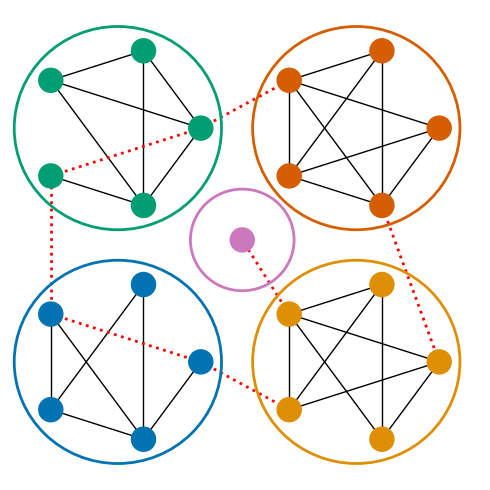

In [ ]:
from torch_geometric.utils import to_networkx
# create from scratch a graph with 4 cliques of size 5
np.random.seed(34)
n = 21
clusters =[[i for i in range(j*5, (j+1)*5)] for j in range(4)]
clusters += [[20]]

sus_edges = [(0,2), (10,13)]
inter_edges = [(0, 8), (10, 17),  (2, 13), (5, 19), ( 7, 20)]

# edges = []
# for cluster in clusters:
#     for u, v in itertools.combinations(cluster, 2):
#         # with p=0.2 do not add the edge
#         if np.random.rand() > 0.175:
#             edges.append((u, v))

# # append some random edges between clusters
# inter_edges = [(0, 8), (10, 17),  (13, 2), (19, 5), (20, 7)]
# intra_edges = edges.copy()

# 
# intra_edges = [e for e in intra_edges if e not in sus_edges]

# edges.extend(inter_edges)

# # now create positions for each node in circles
# pos = {}
# for i in range(4):
#     angle = 2 * np.pi / 5
#     radius = 8
#     center_x = (i % 2) * 23
#     center_y = (i // 2) * 23
#     for j in range(5):
#         x = center_x + radius * np.cos(j * angle)
#         y = center_y + radius * np.sin(j * angle)
#         pos[i * 5 + j] = (x, y)

# pos[20] = (12.0, 12.0)

# colors = []
# # use a colorblind friendly palette
# color_names = sns.color_palette("colorblind", 5).as_hex()
# for i in range(5):
#     colors.extend([color_names[i]] * len(clusters[i]))


# G = nx.Graph(nodes=range(n))
# G.add_edges_from(edges)
# print(G.number_of_nodes())
# print(G.number_of_edges())

edges = list(G.edges())
intra_edges = [e for e in edges if e not in sus_edges and e not in inter_edges]




# draw inter-cluster edges in red and dotted
fig, ax = plt.subplots(figsize=(5, 5))
nx.draw_networkx_nodes(G, pos, node_color=colors)

# draw intra-cluster edges in black and solid
nx.draw_networkx_edges(G, pos, edgelist=intra_edges, edge_color='black', style='solid')

# draw inter-cluster edges in red and dotted
nx.draw_networkx_edges(G, pos, edgelist=inter_edges, edge_color='red', style='dotted', width=2)
# draw suspicious edges in red and dashed
nx.draw_networkx_edges(G, pos, edgelist=sus_edges, edge_color='red', style='dotted', width=2)

# draw a circle around each cluster
for i, cluster in enumerate(clusters):
    radius = 10 if i < 4 else 5
    circle = plt.Circle((np.mean([pos[node][0] for node in cluster]), np.mean([pos[node][1] for node in cluster])), radius, color=color_names[i], fill=False, linewidth=2)
    ax.add_artist(circle)

plt.tight_layout()
# remove black border
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.show()
#fig.savefig('./results/final/example_graph_reduced.pdf')


5
5


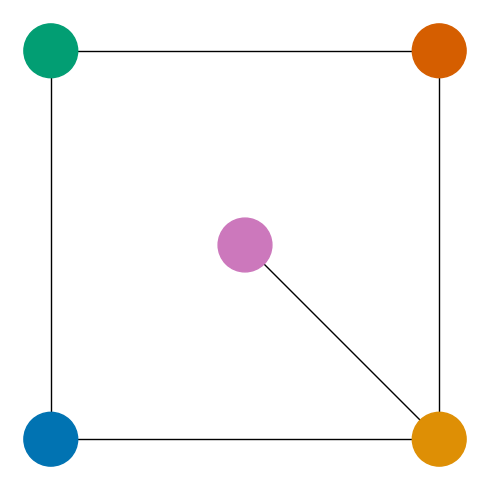

In [8]:
from torch_geometric.utils import to_networkx
# create from scratch a graph with 4 cliques of size 5
n = 5
clusters =[[i,] for i in range(5)]
edges = []
# append some random edges between clusters
inter_edges = [(0, 1), (1,3), (2,3), (2, 0), (4, 1), ]
edges.extend(inter_edges)

# now create positions for each node in circles
pos = {}
for i in range(4):
    angle = 2 * np.pi / 5
    radius = 0
    center_x = (i % 2) * 2
    center_y = (i // 2) * 2
    for j in range(5):
        x = center_x + radius * np.cos(j * angle)
        y = center_y + radius * np.sin(j * angle)
        pos[i] = (x, y)

pos[4] = (1.0, 1.0)

colors = []
# use a colorblind friendly palette
color_names = sns.color_palette("colorblind", 5).as_hex()
for i in range(5):
    colors.extend([color_names[i]])
# swap colors of node  node 2 and 3
colors[3], colors[2] = colors[2], colors[3]

G = nx.Graph(nodes=range(n))
G.add_edges_from(edges)
print(G.number_of_nodes())
print(G.number_of_edges())


# draw inter-cluster edges in red and dotted
fig, ax = plt.subplots(figsize=(5, 5))
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1500)

# draw intra-cluster edges in black and solid
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color='black', style='solid')


plt.tight_layout()
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.show()
#fig.savefig('./results/final/example_graph_pooled.pdf')
